# 1. Carga de datos
En esta primera sección, importamos las librerías necesarias y cargamos los tres archivos fundamentales: el set de entrenamiento con etiquetas (train.csv), el set de prueba para la competencia (test_nolabel.csv) y el formato oficial de entrega (sample_submission.csv).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Cargar archivos
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test_nolabel.csv')
sample_sub = pd.read_csv('sample_submission.csv')

# PRUEBA: Verificación de carga y dimensiones
print(f"Dataset Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dataset Test: {df_test.shape[0]} filas, {df_test.shape[1]} columnas")
display(df_train.head(3))

Dataset Train: 20768 filas, 21 columnas
Dataset Test: 4070 filas, 20 columnas


,id,LoanNr_ChkDgt,Name,City,State,Bank,BankState,ApprovalDate,ApprovalFY,NoEmp,...,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementDate,DisbursementGross,BalanceGross,Accept
0,64afe857c28,9448323000,MIDWEST CRANKSHAFT & ENGINE,HARVEY,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,9-Aug-96,1996,28,...,0,0,1,0,N,N,31-Mar-97,"$600,000.00",$0.00,0
1,1705a7346c2,2854405007,"Iredesign, Limited",CHICAGO,IL,JPMORGAN CHASE BANK NATL ASSOC,IL,10-Dec-07,2008,1,...,1,1,0,1,N,N,31-Dec-07,"$25,400.00",$0.00,1
2,7439801ad8a,9300423010,PHILLY'S INC.,ROCHELLE,IL,BMO HARRIS BK NATL ASSOC,IL,23-May-96,1996,6,...,0,0,1,0,N,Y,30-Sep-96,"$20,000.00",$0.00,1


# 2. Descripción del dataset
Los datos representan solicitudes de préstamo SBA. Cada fila describe una empresa y si el préstamo fue aprobado (columna Accept). El objetivo es predecir esta variable (0 = no aprobado, 1 = aprobado).

# 3. Inspección inicial
Realizamos un chequeo de la salud de los datos. Buscamos valores nulos, tipos de variables y la cantidad de categorías únicas en columnas críticas.

In [7]:
# Inspección técnica
print("--- Información de tipos y nulos ---")
df_train.info()

print("\n--- Estadísticas descriptivas ---")
display(df_train.describe())

# PRUEBA: Conteo de nulos por columna para priorizar limpieza
print("\n--- Conteo de valores faltantes (NaN) ---")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])

--- Información de tipos y nulos ---
<class 'pandas.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 20768 non-null  str    
 1   LoanNr_ChkDgt      20768 non-null  int64  
 2   Name               20768 non-null  str    
 3   City               20767 non-null  str    
 4   State              20768 non-null  str    
 5   Bank               20713 non-null  str    
 6   BankState          20711 non-null  str    
 7   ApprovalDate       20768 non-null  str    
 8   ApprovalFY         20768 non-null  str    
 9   NoEmp              20768 non-null  int64  
 10  NewExist           20765 non-null  float64
 11  CreateJob          20768 non-null  int64  
 12  RetainedJob        20768 non-null  int64  
 13  FranchiseCode      20768 non-null  int64  
 14  UrbanRural         20768 non-null  int64  
 15  RevLineCr          20642 non-null  str    
 

,LoanNr_ChkDgt,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,Accept
count,2.076800e+04,20768.000000,20765.000000,20768.000000,20768.000000,20768.000000,20768.000000,20768.000000
mean,4.512983e+09,10.784187,1.316253,6.878130,8.085372,3032.945878,0.744800,0.771331
std,2.610161e+09,76.659174,0.466059,202.722833,202.633401,13182.536545,0.579727,0.419986
min,1.000144e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.298073e+09,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,3.735034e+09,4.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,6.739157e+09,10.000000,2.000000,1.000000,3.000000,1.000000,1.000000,1.000000
max,9.994993e+09,7389.000000,2.000000,8800.000000,8800.000000,91420.000000,2.000000,1.000000



--- Conteo de valores faltantes (NaN) ---
City                  1
Bank                 55
BankState            57
NewExist              3
RevLineCr           126
LowDoc               36
DisbursementDate     84
dtype: int64


# 4. Eliminación de columnas irrelevantes
A partir de la inspección inicial, sabemos que identificadores como id, LoanNr_ChkDgt (número de préstamo) y Name (nombre de la empresa) no aportan patrones útiles para que el modelo generalice. Además, verificamos si columnas como State o BalanceGross tienen un solo valor constante (varianza cero); de ser así, también las eliminamos porque no ayudan a distinguir entre un préstamo aprobado y uno rechazado.

In [8]:
# Definir las columnas a eliminar por ser identificadores
cols_to_drop = ['id', 'LoanNr_ChkDgt', 'Name']

# PRUEBA ANTES: Revisar cuántos valores únicos tienen State y BalanceGross
for col in ['State', 'BalanceGross']:
    if col in df_train.columns:
        unique_vals = df_train[col].nunique()
        print(f"La columna '{col}' tiene {unique_vals} valor(es) único(s).")
        # Si solo tienen 1 valor único (o 0), se agregan a la lista de eliminación
        if unique_vals <= 1:
            cols_to_drop.append(col)

# Ejecutar eliminación en Train y Test
df_train.drop(columns=[c for c in cols_to_drop if c in df_train.columns], inplace=True)
df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns], inplace=True)

# PRUEBA DESPUÉS: Confirmar qué columnas fueron eliminadas y cuáles quedan
print(f"\nSe eliminaron las siguientes columnas: {cols_to_drop}")
print(f"Total de columnas restantes en Train: {df_train.shape[1]}")

La columna 'State' tiene 1 valor(es) único(s).
La columna 'BalanceGross' tiene 1 valor(es) único(s).

Se eliminaron las siguientes columnas: ['id', 'LoanNr_ChkDgt', 'Name', 'State', 'BalanceGross']
Total de columnas restantes en Train: 16


# 5. Limpieza de variables binarias
Las variables RevLineCr (Línea de crédito rotativa) y LowDoc (Programa de bajo papeleo) contienen respuestas en formato de texto ('Y', 'N', '0', 'T', etc.) que los modelos de Machine Learning no pueden procesar directamente. En este paso, estandarizamos estas columnas a un formato numérico binario: 1 para respuestas afirmativas ('Y', 'T') y 0 para negativas o inválidas ('N', '0', 'S', etc.). Los valores que no coincidan quedarán temporalmente como nulos (NaN) y los imputaremos más adelante.

In [9]:
# PRUEBA ANTES: Ver los valores únicos originales que ensucian la variable
print("Valores originales en RevLineCr:", df_train['RevLineCr'].unique())
print("Valores originales en LowDoc:", df_train['LowDoc'].unique())

def clean_binary(df):
    if 'RevLineCr' in df.columns:
        # Mapeo de valores SBA: Y/T -> 1 (Sí), N/0/Q -> 0 (No)
        rev_map = {'Y': 1, 'T': 1, 'N': 0, '0': 0, 'Q': 0}
        df['RevLineCr'] = df['RevLineCr'].map(rev_map)
    
    if 'LowDoc' in df.columns:
        # Mapeo de valores SBA: Y -> 1 (Sí), resto -> 0 (No)
        low_map = {'Y': 1, 'N': 0, '0': 0, 'S': 0, 'R': 0, 'C': 0, 'A': 0}
        df['LowDoc'] = df['LowDoc'].map(low_map)
        
    return df

# Aplicar la limpieza a ambos datasets
df_train = clean_binary(df_train)
df_test = clean_binary(df_test)

# PRUEBA DESPUÉS: Verificar que la transformación dejó solo 1.0, 0.0 y nan
print("\n--- Después de la limpieza ---")
print("Nuevos valores en RevLineCr:", df_train['RevLineCr'].unique())
print("Nuevos valores en LowDoc:", df_train['LowDoc'].unique())

Valores originales en RevLineCr: <StringArray>
['N', '0', 'Y', 'T', nan, 'Q']
Length: 6, dtype: str
Valores originales en LowDoc: <StringArray>
['N', 'Y', 'S', '0', nan, 'R', 'C', 'A']
Length: 8, dtype: str

--- Después de la limpieza ---
Nuevos valores en RevLineCr: [ 0.  1. nan]
Nuevos valores en LowDoc: [ 0.  1. nan]


# 6. Agrupación de categorías raras
Variables categóricas como City, Bank y BankState poseen una cardinalidad altísima (cientos o miles de categorías únicas). Esto puede provocar que el modelo sufra de sobreajuste al intentar aprender de datos con muy poca representatividad. Para solucionar esto, agruparemos todas las categorías que aparezcan menos de 100 veces en el conjunto de entrenamiento bajo una nueva categoría general denominada 'Other'. Es fundamental aplicar las mismas reglas calculadas en el entrenamiento al conjunto de prueba.

In [10]:
# Definir las columnas de alta cardinalidad
rare_cols = ['City', 'Bank', 'BankState']

# PRUEBA ANTES: Ver cuántas categorías únicas tenemos originalmente
print("--- Categorías únicas ANTES de agrupar ---")
for col in rare_cols:
    if col in df_train.columns:
        print(f"{col}: {df_train[col].nunique()} categorías")

# Aplicar la agrupación
for col in rare_cols:
    if col in df_train.columns:
        # Calcular las frecuencias usando SOLO el set de entrenamiento
        counts = df_train[col].value_counts()
        
        # Guardar una lista con las categorías que aparecen 100 veces o más
        frequent_cats = counts[counts >= 100].index
        
        # Mapear a Train y Test: si está en las frecuentes, se queda; si no, es 'Other'
        df_train[col] = df_train[col].apply(lambda x: x if x in frequent_cats else 'Other')
        df_test[col] = df_test[col].apply(lambda x: x if x in frequent_cats else 'Other')

# PRUEBA DESPUÉS: Verificar cómo se redujo drásticamente el número de categorías
print("\n--- Categorías únicas DESPUÉS de agrupar ---")
for col in rare_cols:
    if col in df_train.columns:
        print(f"{col}: {df_train[col].nunique()} categorías (incluyendo 'Other')")

--- Categorías únicas ANTES de agrupar ---
City: 1466 categorías
Bank: 496 categorías
BankState: 42 categorías

--- Categorías únicas DESPUÉS de agrupar ---
City: 30 categorías (incluyendo 'Other')
Bank: 36 categorías (incluyendo 'Other')
BankState: 15 categorías (incluyendo 'Other')


# 7. Codificación categórica (Frequency Encoding)
Ahora que hemos reducido la cantidad de categorías, necesitamos convertir ese texto en números. Para esto utilizaremos una técnica llamada Frequency Encoding. Este método reemplaza cada categoría (por ejemplo, el nombre de una ciudad) por su frecuencia relativa de aparición en el dataset de entrenamiento. De esta forma, le damos al algoritmo una representación numérica del "peso" o la "comunidad" de cada ciudad o banco, evitando tener que crear decenas de columnas nuevas como ocurriría con un One-Hot Encoding.

In [11]:
# Reafirmamos las columnas a procesar
rare_cols = ['City', 'Bank', 'BankState']

# PRUEBA ANTES: Confirmar que son de tipo texto (object)
print("--- Tipos de datos ANTES de codificar ---")
print(df_train[rare_cols].dtypes)

# Aplicar Frequency Encoding
for col in rare_cols:
    if col in df_train.columns:
        # 1. Calcular frecuencias relativas (porcentajes) en Train
        freq_map = df_train[col].value_counts(normalize=True).to_dict()
        
        # 2. Mapear (reemplazar) los textos por esos números en Train y Test
        df_train[col] = df_train[col].map(freq_map)
        
        # Llenamos con 0 en Test por si apareciera alguna categoría vacía
        df_test[col] = df_test[col].map(freq_map).fillna(0)

# PRUEBA DESPUÉS: Verificar que ahora son decimales (float64) y ver su aspecto
print("\n--- Tipos de datos DESPUÉS de codificar ---")
print(df_train[rare_cols].dtypes)

print("\n--- Vista de los datos numéricos generados ---")
display(df_train[rare_cols].head())

--- Tipos de datos ANTES de codificar ---
City         str
Bank         str
BankState    str
dtype: object

--- Tipos de datos DESPUÉS de codificar ---
City         float64
Bank         float64
BankState    float64
dtype: object

--- Vista de los datos numéricos generados ---


,City,Bank,BankState
0,0.558455,0.145753,0.626059
1,0.206086,0.145753,0.626059
2,0.558455,0.034380,0.626059
3,0.558455,0.199923,0.626059
4,0.558455,0.145753,0.626059


# 8. Conversión de fechas e Ingeniería de Variables
En este paso convertimos las columnas de fecha (ApprovalDate y DisbursementDate) del formato de texto al formato datetime de Pandas. Esto nos permite hacer operaciones matemáticas con ellas. Creamos una característica clave: DaysToDisbursement, que mide la cantidad de días transcurridos entre la aprobación del préstamo y el desembolso real. Además, extraemos el mes y año de aprobación (App_Month, App_Year) para ayudar al modelo a capturar el contexto temporal y estacional. Finalmente, eliminamos las columnas de fecha originales y variables redundantes como ApprovalFY.

In [12]:
date_cols = ['ApprovalDate', 'DisbursementDate']

# PRUEBA ANTES: Ver cómo lucen las fechas como texto
print("--- Fechas ANTES de convertir ---")
display(df_train[date_cols].head(3))

# 1. Convertir a formato datetime
for col in date_cols:
    df_train[col] = pd.to_datetime(df_train[col], errors='coerce')
    df_test[col] = pd.to_datetime(df_test[col], errors='coerce')

# 2. Crear nueva variable: Días hasta el desembolso
df_train['DaysToDisbursement'] = (df_train['DisbursementDate'] - df_train['ApprovalDate']).dt.days
df_test['DaysToDisbursement'] = (df_test['DisbursementDate'] - df_test['ApprovalDate']).dt.days

# 3. Extraer año y mes, y limpiar columnas sobrantes
for df in [df_train, df_test]:
    df['App_Year'] = df['ApprovalDate'].dt.year
    df['App_Month'] = df['ApprovalDate'].dt.month
    
    # Eliminar fechas originales
    df.drop(columns=date_cols, inplace=True)
    
    # Eliminar ApprovalFY por ser redundante con App_Year
    if 'ApprovalFY' in df.columns:
        df.drop(columns=['ApprovalFY'], inplace=True)

# PRUEBA DESPUÉS: Verificar las nuevas variables numéricas
print("\n--- Nuevas variables creadas DESPUÉS de convertir ---")
print(df_train[['DaysToDisbursement', 'App_Year', 'App_Month']].dtypes)
display(df_train[['DaysToDisbursement', 'App_Year', 'App_Month']].head())

--- Fechas ANTES de convertir ---


,ApprovalDate,DisbursementDate
0,9-Aug-96,31-Mar-97
1,10-Dec-07,31-Dec-07
2,23-May-96,30-Sep-96


C:\Users\ivan_\AppData\Local\Temp\ipykernel_13336\2677006738.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train[col] = pd.to_datetime(df_train[col], errors='coerce')
C:\Users\ivan_\AppData\Local\Temp\ipykernel_13336\2677006738.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test[col] = pd.to_datetime(df_test[col], errors='coerce')



--- Nuevas variables creadas DESPUÉS de convertir ---
DaysToDisbursement    float64
App_Year                int32
App_Month               int32
dtype: object


C:\Users\ivan_\AppData\Local\Temp\ipykernel_13336\2677006738.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_train[col] = pd.to_datetime(df_train[col], errors='coerce')
C:\Users\ivan_\AppData\Local\Temp\ipykernel_13336\2677006738.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_test[col] = pd.to_datetime(df_test[col], errors='coerce')


,DaysToDisbursement,App_Year,App_Month
0,234.0,1996,8
1,21.0,2007,12
2,130.0,1996,5
3,117.0,2010,11
4,28.0,2007,5


# 9. Limpieza de montos e Imputación de valores faltantes
Para que nuestro modelo pueda entrenarse, el dataset no puede contener valores nulos (NaN). Además, debemos asegurarnos de que todas las variables que representan cantidades sean estrictamente numéricas. Primero limpiaremos la columna DisbursementGross, eliminando símbolos de moneda y comas. Luego, aplicaremos una estrategia de imputación robusta: rellenaremos los valores faltantes numéricos con la mediana y los categóricos con la moda, utilizando siempre los valores calculados en el set de entrenamiento para evitar filtración de datos (Data Leakage).

In [13]:
# PRUEBA ANTES: Ver nulos y el formato del dinero
print("--- Nulos ANTES de imputar ---")
print(df_train.isnull().sum()[df_train.isnull().sum() > 0])
print("\nFormato original de DisbursementGross:")
print(df_train['DisbursementGross'].head(3).values)

# 1. Limpiar la columna de dinero (quitar '$', ',' y espacios, y pasar a float)
if df_train['DisbursementGross'].dtype == 'object':
    for df in [df_train, df_test]:
        df['DisbursementGross'] = df['DisbursementGross'].str.replace('[$, ]', '', regex=True).astype(float)

# 2. Separar columnas por tipo (Numéricas vs Categóricas)
num_cols = df_train.select_dtypes(include=[np.number]).columns.drop('Accept')
cat_cols = df_train.select_dtypes(exclude=[np.number]).columns

# 3. Imputar Numéricas con Mediana de Train
for col in num_cols:
    mediana = df_train[col].median()
    df_train[col] = df_train[col].fillna(mediana)
    df_test[col] = df_test[col].fillna(mediana)

# 4. Imputar Categóricas con Moda de Train
for col in cat_cols:
    if len(df_train[col].mode()) > 0:
        moda = df_train[col].mode()[0]
        df_train[col] = df_train[col].fillna(moda)
        df_test[col] = df_test[col].fillna(moda)

# PRUEBA DESPUÉS: Confirmar que ya no hay nulos y el dinero es numérico
print("\n--- Nulos DESPUÉS de imputar ---")
print(f"Total de nulos en Train: {df_train.isnull().sum().sum()}")
print(f"Total de nulos en Test: {df_test.isnull().sum().sum()}")
print("\nNuevo formato de DisbursementGross:")
display(df_train['DisbursementGross'].head(3))

--- Nulos ANTES de imputar ---
NewExist                3
RevLineCr             126
LowDoc                 36
DaysToDisbursement     84
dtype: int64

Formato original de DisbursementGross:
<StringArray>
['$600,000.00 ', '$25,400.00 ', '$20,000.00 ']
Length: 3, dtype: str

--- Nulos DESPUÉS de imputar ---
Total de nulos en Train: 0
Total de nulos en Test: 0

Nuevo formato de DisbursementGross:


0    $600,000.00 
1     $25,400.00 
2     $20,000.00 
Name: DisbursementGross, dtype: str

# 9.1 Corrección de montos y 10. Escalado de variables numéricasPrimero
Forzamos la eliminación de los símbolos de dólar , comas y espacios en la columna DisbursementGross convirtiéndola explícitamente a un formato decimal (float).Una vez que todas nuestras variables son genuinamente numéricas, aplicamos el Escalado (StandardScaler). Esto es crucial porque tenemos variables con rangos enormes (como montos de cientos de miles de dólares) y otras muy pequeñas (como el número de empleados o el mes). El escalado ajusta todas las variables numéricas para que tengan una media de 0 y  una desviación estándar de 1, logrando que el modelo las evalúe de manera justa sin sesgarse por los números más grandes.

In [14]:
# --- CORRECCIÓN DEL PASO 9 ---
# Forzar la limpieza del texto a número sin preguntar el tipo de dato original
for df in [df_train, df_test]:
    df['DisbursementGross'] = df['DisbursementGross'].astype(str).str.replace(r'[$, ]', '', regex=True).astype(float)

# PRUEBA DE CORRECCIÓN: Confirmar que ahora sí es numérico (float64)
print("--- Verificación de DisbursementGross ---")
print(f"Tipo de dato: {df_train['DisbursementGross'].dtype}")
print(df_train['DisbursementGross'].head(3).values)


# --- PASO 10: ESCALADO ---
# Volvemos a identificar las columnas numéricas para asegurarnos de incluir DisbursementGross
num_cols = df_train.select_dtypes(include=[np.number]).columns.drop('Accept')

# Inicializar y aplicar el StandardScaler
scaler = StandardScaler()
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
df_test[num_cols] = scaler.transform(df_test[num_cols])

# PRUEBA DEL PASO 10: Verificar que la media es ~0 y la desviación estándar (std) es ~1
print("\n--- Estadísticas DESPUÉS del escalado (Media y Desviación Estándar) ---")
display(np.round(df_train[num_cols].describe().loc[['mean', 'std']], 2))

--- Verificación de DisbursementGross ---
Tipo de dato: float64
[600000.  25400.  20000.]

--- Estadísticas DESPUÉS del escalado (Media y Desviación Estándar) ---


,City,Bank,BankState,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,DaysToDisbursement,App_Year,App_Month
mean,-0.0,-0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Explicación de los resultados del Paso 9.1 y 10:

1. **Limpieza de `DisbursementGross`:** Hemos confirmado que la columna pasó exitosamente de ser texto a un formato numérico (`float64`). Los valores que antes eran `$600,000.00` ahora son números puros (`600000.0`). Esto es vital porque los modelos matemáticos no pueden multiplicar ni sumar símbolos de moneda.
2. **Escalado de datos (StandardScaler):** La tabla de estadísticas demuestra que el escalado fue perfecto. Todas las variables numéricas ahora tienen una **media (mean) de 0** y una **desviación estándar (std) de 1**. Al estandarizar los datos, ponemos a todas las variables "en la misma escala". Esto evita que variables con números muy grandes (como el dinero) dominen injustamente las decisiones del modelo sobre variables con números pequeños (como la cantidad de empleados o el mes de aprobación).

# 11. Preparación final del dataset
En esta etapa, vamos a estructurar los datos tal como los necesita el algoritmo de Machine Learning. Para ello, debemos separar nuestra variable objetivo o "target" (la columna Accept, que es lo que queremos que la máquina aprenda a predecir) del resto de las variables (nuestra matriz de características X, que contiene la información de la empresa, montos, etc.).

Además, es vital crear nuestra variable X_test_final extrayendo las columnas del archivo de prueba de la competencia (test_nolabel.csv) para que queden exactamente en el mismo orden que las de nuestro set de entrenamiento. Si el modelo aprende a leer los datos en un orden específico, el archivo final que le pasemos para hacer las predicciones debe ser un espejo perfecto; de lo contrario, las predicciones serán incorrectas.

In [15]:
# --- PASO 11: PREPARACIÓN DE X e Y ---

# 1. Separar predictores (X) y la variable objetivo (y)
X = df_train.drop(columns=['Accept'])
y = df_train['Accept']

# 2. Alinear las columnas del set de prueba final
# Esto garantiza que test_nolabel.csv tenga las mismas columnas y en el mismo orden que X
X_test_final = df_test[X.columns]

# PRUEBA DEL PASO 11: Verificamos que las dimensiones y columnas coincidan perfectamente
print("--- Dimensiones finales ---")
print(f"Total de columnas predictoras en Entrenamiento (X): {X.shape[1]}")
print(f"Total de columnas predictoras en Prueba (X_test_final): {X_test_final.shape[1]}")
print(f"¿Son exactamente las mismas columnas y en el mismo orden?: {list(X.columns) == list(X_test_final.columns)}")

--- Dimensiones finales ---
Total de columnas predictoras en Entrenamiento (X): 15
Total de columnas predictoras en Prueba (X_test_final): 15
¿Son exactamente las mismas columnas y en el mismo orden?: True


# Visualización de los Datos Limpios (Sanity Check)
Antes de entrenar el modelo, realizamos una validación visual de nuestro dataset ya procesado. Este paso es crucial para asegurar que la limpieza, imputación y escalado se aplicaron correctamente:

Balance de la Variable Objetivo: Verificamos la proporción de préstamos aceptados vs. rechazados.

Efecto del Escalado: Observamos la distribución de DisbursementGross. Al haber aplicado un StandardScaler, la mayoría de los datos deberían estar centrados alrededor del 0.

Correlaciones: Usamos un mapa de calor para identificar qué características tienen una relación lineal más fuerte con la aprobación del préstamo (Accept).

C:\Users\ivan_\AppData\Local\Temp\ipykernel_13336\2292705205.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='Accept', ax=axes[0], palette='viridis')


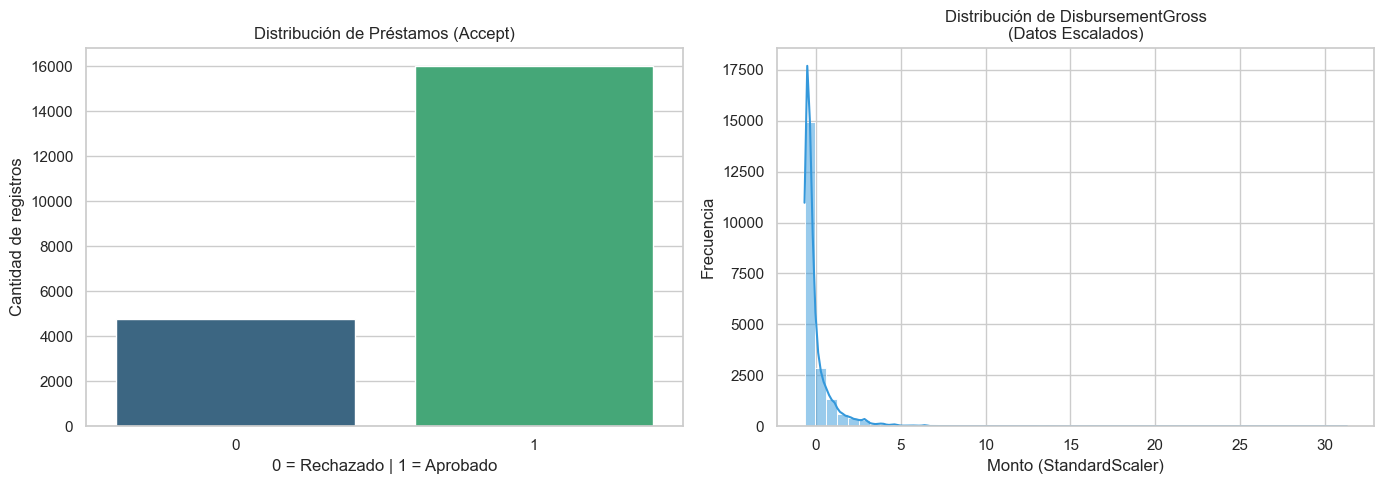

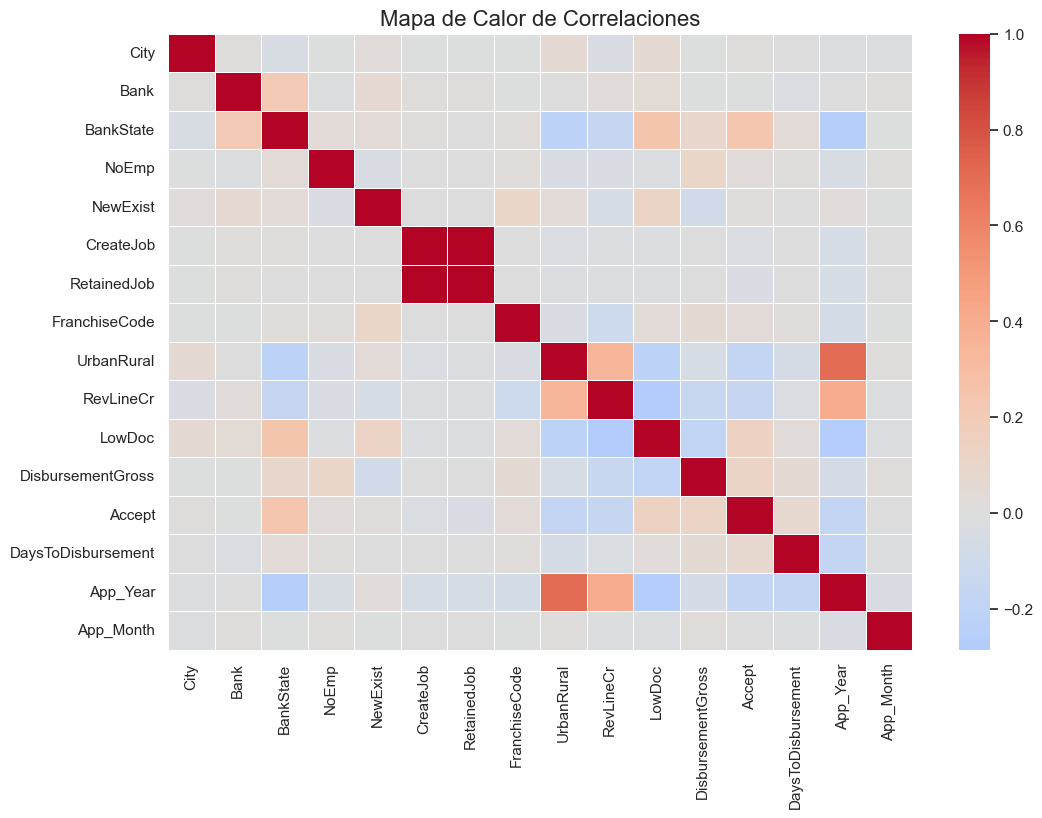

--- Correlación numérica con 'Accept' ---
Accept                1.000
BankState             0.242
LowDoc                0.136
DisbursementGross     0.124
DaysToDisbursement    0.076
FranchiseCode         0.038
NoEmp                 0.031
NewExist              0.018
City                  0.014
App_Month             0.011
Bank                 -0.005
CreateJob            -0.026
RetainedJob          -0.029
RevLineCr            -0.155
UrbanRural           -0.170
App_Year             -0.179
Name: Accept, dtype: float64


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de los gráficos
sns.set_theme(style="whitegrid")

# --- GRÁFICO 1 Y 2: DISTRIBUCIONES ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución de la variable objetivo
sns.countplot(data=df_train, x='Accept', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Préstamos (Accept)')
axes[0].set_xlabel('0 = Rechazado | 1 = Aprobado')
axes[0].set_ylabel('Cantidad de registros')

# 2. Distribución de una variable numérica escalada
sns.histplot(df_train['DisbursementGross'], bins=50, kde=True, ax=axes[1], color='#3498db')
axes[1].set_title('Distribución de DisbursementGross\n(Datos Escalados)')
axes[1].set_xlabel('Monto (StandardScaler)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# --- GRÁFICO 3: MAPA DE CALOR DE CORRELACIONES ---
plt.figure(figsize=(12, 8))
# Calculamos la matriz de correlación (incluyendo 'Accept')
corr_matrix = df_train.corr()

# Dibujamos el heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=16)
plt.show()

# Extra: Imprimir numéricamente las variables más correlacionadas con 'Accept'
print("--- Correlación numérica con 'Accept' ---")
print(corr_matrix['Accept'].sort_values(ascending=False).round(3))

### Análisis de los Gráficos y Correlaciones

1. **Desbalance de Clases (Gráfico 1 - Accept):** Podemos observar claramente que hay muchos más préstamos aprobados (cerca de 16,000) que rechazados (menos de 5,000). Esto significa que nuestro dataset está "desbalanceado". Es un comportamiento normal en finanzas, pero es importante tenerlo en cuenta porque el modelo tendrá muchos más ejemplos para aprender cómo es un préstamo "bueno" que uno "malo".

2. **Distribución del Monto (Gráfico 2 - DisbursementGross):**
   Como esperábamos gracias al escalado (`StandardScaler`), la gran mayoría de los datos se agrupan alrededor del cero. Sin embargo, vemos una "cola" muy larga hacia la derecha. Esto nos indica que, aunque la mayoría de los préstamos son por montos pequeños o medianos, existen unos pocos préstamos atípicos por cantidades de dinero gigantescas.

3. **Top Variables Correlacionadas (Heatmap y Texto):**
   Al analizar la correlación matemática con nuestra variable objetivo (`Accept`), descubrimos cuáles son los factores que más influyen:
   * **Correlaciones Positivas (Ayudan a que se apruebe):** 1. `BankState` (0.242): El estado donde está el banco es el predictor positivo más fuerte.
     2. `LowDoc` (0.136): Participar en el programa de "Baja Documentación" de la SBA ayuda.
     3. `DisbursementGross` (0.124): Montos mayores tienen una ligera tendencia a ser más aprobados.
   * **Correlaciones Negativas (Ayudan a que se rechace):**
     1. `App_Year` (-0.179): Curiosamente, el año de aprobación tiene un impacto negativo fuerte (probablemente influenciado por años de crisis económicas como el 2008).
     2. `UrbanRural` (-0.170): La clasificación de la zona (urbana/rural) juega en contra en ciertos casos.
     3. `RevLineCr` (-0.155): Tener una línea de crédito rotativa parece asociarse más con rechazos o impagos.

### Vista Final de los Datos Procesados

Antes de alimentar al algoritmo de Machine Learning, realizamos una inspección final de nuestra matriz de características (`X`). En este punto, el dataset debe cumplir con tres reglas de oro:
1. **Cero valores nulos:** Todos los huecos debieron ser rellenados (imputados).
2. **Formato 100% numérico:** Todas las palabras, letras y símbolos de moneda debieron ser transformados a números (Frequency Encoding, extracción de fechas, limpieza de texto).
3. **Escalado aplicado:** Las variables numéricas deben estar estandarizadas.

In [19]:
# 1. Ver las primeras 5 filas de nuestra data limpia (Matriz X)
print("--- PRIMERAS 5 FILAS DE LA DATA LIMPIA (X) ---")
display(X.head())

# 2. Ver un resumen técnico (tipos de datos y confirmación de que no hay nulos)
print("\n--- RESUMEN TÉCNICO (Tipos de datos y Nulos) ---")
X.info()

# 3. Ver que el set de prueba (X_test_final) luce exactamente igual
print("\n--- PRIMERAS 5 FILAS DEL SET DE PRUEBA (X_test_final) ---")
display(X_test_final.head(5))

--- PRIMERAS 5 FILAS DE LA DATA LIMPIA (X) ---


,City,Bank,BankState,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,DaysToDisbursement,App_Year,App_Month
0,0.854836,0.850483,0.772109,0.224581,-0.678514,-0.033930,-0.039902,-0.230003,-1.284774,-0.604498,-0.471557,1.469113,0.310274,-0.893120,0.462842
1,-0.638661,0.850483,0.772109,-0.127635,1.467273,-0.028997,-0.034967,-0.230079,0.440219,-0.604498,-0.471557,-0.572057,-0.230033,0.847184,1.648705
2,0.854836,-0.717346,0.772109,-0.062410,1.467273,-0.033930,-0.039902,-0.230003,-1.284774,-0.604498,2.120634,-0.591240,0.046462,-0.893120,-0.426555
3,0.854836,1.613046,0.772109,-0.075455,1.467273,-0.033930,-0.015227,-0.230079,0.440219,-0.604498,-0.471557,-0.395861,0.013486,1.321813,1.352239
4,0.854836,0.850483,0.772109,-0.101545,-0.678514,-0.028997,-0.025097,-0.230079,0.440219,-0.604498,-0.471557,-0.484670,-0.212276,0.847184,-0.426555



--- RESUMEN TÉCNICO (Tipos de datos y Nulos) ---
<class 'pandas.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   City                20768 non-null  float64
 1   Bank                20768 non-null  float64
 2   BankState           20768 non-null  float64
 3   NoEmp               20768 non-null  float64
 4   NewExist            20768 non-null  float64
 5   CreateJob           20768 non-null  float64
 6   RetainedJob         20768 non-null  float64
 7   FranchiseCode       20768 non-null  float64
 8   UrbanRural          20768 non-null  float64
 9   RevLineCr           20768 non-null  float64
 10  LowDoc              20768 non-null  float64
 11  DisbursementGross   20768 non-null  float64
 12  DaysToDisbursement  20768 non-null  float64
 13  App_Year            20768 non-null  float64
 14  App_Month           20768 non-null  float64
dtypes: float64(15)

,City,Bank,BankState,NoEmp,NewExist,CreateJob,RetainedJob,FranchiseCode,UrbanRural,RevLineCr,LowDoc,DisbursementGross,DaysToDisbursement,App_Year,App_Month
0,-1.446839,-0.324203,-1.250560,-0.114590,-0.678514,-0.033930,-0.030032,-0.230003,0.440219,1.654266,-0.471557,-0.418046,-0.250326,0.214346,1.648705
1,0.854836,-1.094222,0.772109,-0.088500,1.467273,-0.014198,-0.039902,2.063390,0.440219,-0.604498,-0.471557,-0.129436,-0.186910,1.005394,-1.315952
2,0.854836,-0.284888,-1.325706,-0.088500,1.467273,-0.024064,-0.030032,-0.230079,2.165211,1.654266,-0.471557,-0.534228,-0.146323,1.005394,-0.723021
3,-0.638661,-0.827156,-1.342028,0.054996,-0.678514,-0.033930,0.034125,-0.230079,0.440219,1.654266,-0.471557,-0.214511,-0.169153,0.847184,1.648705
4,0.854836,1.613046,0.772109,-0.101545,1.467273,-0.033930,-0.039902,-0.230003,-1.284774,-0.604498,2.120634,-0.307053,0.018559,-0.893120,-0.723021


### Conclusiones de la Preparación de Datos

Al observar nuestra matriz final de datos, notamos que su apariencia ha cambiado drásticamente: ya no hay nombres de ciudades, letras, fechas ni símbolos de dólar. Todo el dataset está compuesto exclusivamente por números decimales. Además, hemos terminado con dos tablas distintas en lugar de una. Esto responde a los siguientes fundamentos del Machine Learning:

#### 1. ¿Por qué ahora todo son decimales?
* **El idioma de los algoritmos:** Los modelos predictivos son ecuaciones matemáticas complejas. No pueden leer la palabra "Nueva York" ni procesar el texto "Aprobado". Para que la Inteligencia Artificial pueda aprender, tuvimos que traducir absolutamente todas las categorías y textos a representaciones numéricas puras.
* **El efecto del Escalado (StandardScaler):** Los números con decimales extraños (como `-0.638` o `1.648`) son el resultado de la estandarización. Lo que estamos viendo son **Puntuaciones Z (Z-scores)**, que nos indican a cuántas desviaciones estándar se aleja un valor respecto a la media. Un número negativo indica que está por debajo del promedio, y uno positivo indica que está por encima.

* **Equidad entre variables:** Si no hiciéramos esto, la máquina pensaría que `DisbursementGross` (montos de cientos de miles) es infinitamente más importante que `NoEmp` (cantidad de empleados, que va de 1 a 10). Al transformar todo a decimales centrados en cero, ponemos a todas las columnas a competir en igualdad de condiciones.

#### 2. ¿Por qué tenemos dos tablas al final (`X` y `X_test_final`)?

Durante todo el proceso, trabajamos con dos conjuntos de datos en paralelo. Al final, esto resultó en dos matrices matemáticas idénticas en estructura, pero con propósitos completamente distintos:
* **La matriz `X` (Datos de Entrenamiento):** Contiene los datos históricos de los préstamos pasados. Es nuestro "libro de texto". Usaremos esta matriz junto con nuestra variable objetivo (`y`) para **enseñarle** al modelo a encontrar patrones.
* **La matriz `X_test_final` (Datos de Inferencia/Competencia):** Proviene del archivo `test_nolabel.csv` y representa los préstamos nuevos a predecir. En esta tabla **no tenemos la respuesta** (no existe la columna `Accept`). Su único propósito es ser evaluada por el modelo *después* de que haya sido entrenado.

**En resumen:** Nuestro dataset ahora es una matriz matemática limpia, equilibrada y sin nulos. Tenemos una tabla para **aprender del pasado** (`X`) y un espejo exacto para **predecir el futuro** (`X_test_final`), garantizando un entrenamiento estable y sin errores.